# COMM 187: Data Science in Communication Research, Winter 2026

## Week #8: Data Visualization using seaborn - II

Welcome to the Week #8 Coding Lab for COMM 187: Data Science in Communication Research! 

Today's lesson plan:
 - Violin plots
 - Joint plots

In the past two weeks, we have learned the following types of plots:

 - **Histograms** -- for visualizing data distribution and description
 - **Scatterplots** -- for visualizing relationships between two variables
 - **Box plots** -- for visualizing difference in means between groups; ideal for visualizing t-tests and ANOVA

Let's start with importing the required Python packages and importing our dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('./data/recent-grads.csv')

### Practicing Boxplot and `.isin()` method
Create a boxplot showing the difference in share of women for the major categories "Physical Sciences", "Law & Public Policy", and "Biology & Life Science".

In [2]:
df.columns

Index(['Rank', 'Major_code', 'Major', 'Total', 'Men', 'Women',
       'Major_category', 'ShareWomen', 'Sample_size', 'Employed', 'Full_time',
       'Part_time', 'Full_time_year_round', 'Unemployed', 'Unemployment_rate',
       'Income', 'P25th', 'P75th', 'College_jobs', 'Non_college_jobs',
       'Low_wage_jobs'],
      dtype='object')

Text(0.5, 1.0, 'Share of Women by Major Category')

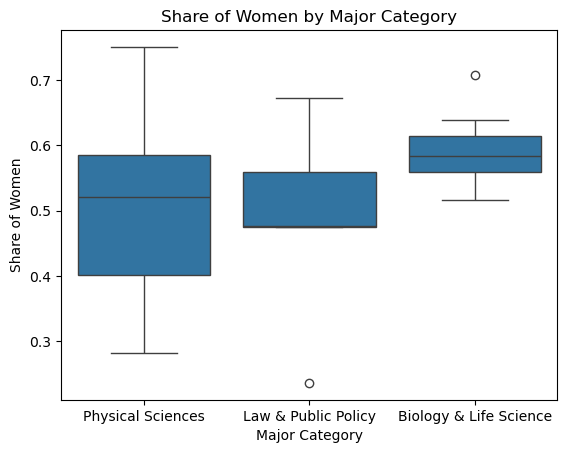

In [5]:
### Your code below this line
indices_for_subset = df['Major_category'].isin(['Physical Sciences', 'Law & Public Policy', 'Biology & Life Science'])
df_subset = df[indices_for_subset]

sns.boxplot(data = df_subset, x = 'Major_category', y = 'ShareWomen')

plt.xlabel('Major Category')
plt.ylabel('Share of Women')
plt.title('Share of Women by Major Category')

### **Violin Plots**

A **violin plot** combines a box plot with a kernel density plot on each side, creating a "violin" shape. Like box plots, they show median, quartiles, and range. **The key addition is the width of the violin at any point represents how common that value is in the data - wider sections mean more data points at that value.** This reveals the full distribution shape, showing whether data is bimodal (two peaks), skewed, or has other patterns that box plots hide. Particularly useful when comparing distributions across multiple groups side-by-side.

In seaborn package, you can make violin plots using the `violinplot` function. Read more in the documentation [here](https://seaborn.pydata.org/generated/seaborn.violinplot.html).

Let's start with replicating the box plot that we just practiced into a violin plot. All you need to do is replace `boxplot` with `violinplot` -- try it!

Text(0.5, 1.0, 'Share of Women by Major Category')

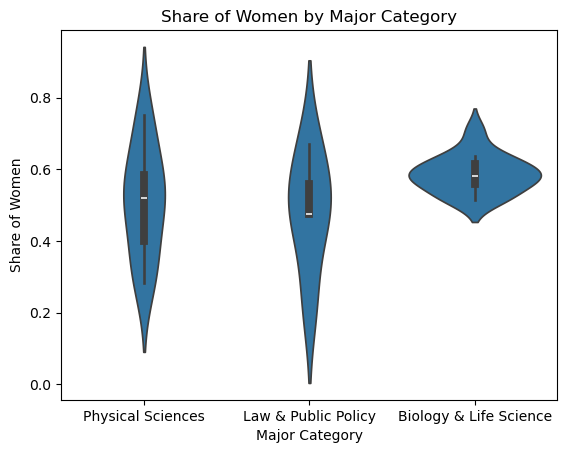

In [6]:
### Your code below this line
indices_for_subset = df['Major_category'].isin(['Physical Sciences', 'Law & Public Policy', 'Biology & Life Science'])
df_subset = df[indices_for_subset]

sns.violinplot(data = df_subset, x = 'Major_category', y = 'ShareWomen')

plt.xlabel('Major Category')
plt.ylabel('Share of Women')
plt.title('Share of Women by Major Category')

Now, make the color of the violin plots green. You can do this by adding the following parameter to the `violinplot` function: `color = 'green'`. Try it!

Text(0.5, 1.0, 'Share of Women by Major Category')

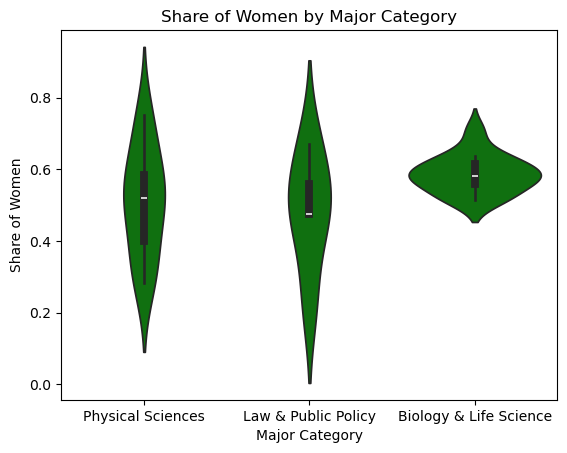

In [7]:
### Your code below this line
indices_for_subset = df['Major_category'].isin(['Physical Sciences', 'Law & Public Policy', 'Biology & Life Science'])
df_subset = df[indices_for_subset]

sns.violinplot(data = df_subset, x = 'Major_category', y = 'ShareWomen', color = 'green')

plt.xlabel('Major Category')
plt.ylabel('Share of Women')
plt.title('Share of Women by Major Category')

The green color looks too stark. Let's reduce the intensity. We can do that by adjusting the **transparency** of the color, using the `alpha` parameter. If the value of `alpha` is 0, that means the transparency is 0, and the color is fully opaque. If the value of `alpha` is 1, then it means that the color is fully transparent, and effectively absent. We want to try a value between 0 and 1, let's say, 0.5. 

Add the parameter `alpha = 0.5` to the violinplot to adjust the transparency of the green color. Try it!

Text(0.5, 1.0, 'Share of Women by Major Category')

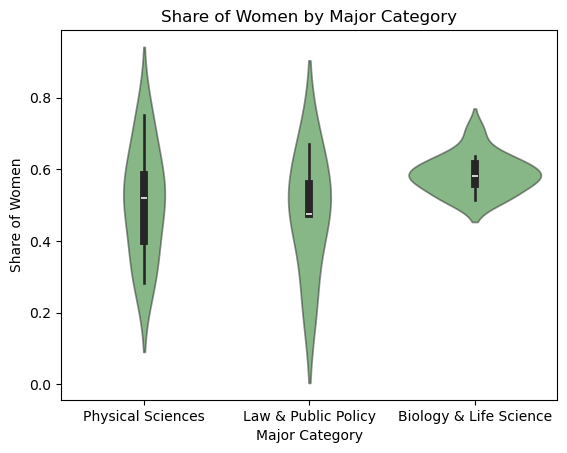

In [10]:
### Your code below this line
indices_for_subset = df['Major_category'].isin(['Physical Sciences', 'Law & Public Policy', 'Biology & Life Science'])
df_subset = df[indices_for_subset]

sns.violinplot(data = df_subset, x = 'Major_category', y = 'ShareWomen', color = 'green', alpha = 0.5)

plt.xlabel('Major Category')
plt.ylabel('Share of Women')
plt.title('Share of Women by Major Category')

#### Practice Question

Create a violin plot showing the difference in 75th percentile of earnings (`P75th`) for the major categories "Business", "Psychology & Social Work", and "Industrial Arts & Consumer Services", in purple color, and 0.7 color transparency level.

Text(0.5, 1.0, '75th percentile of earning by Major Category')

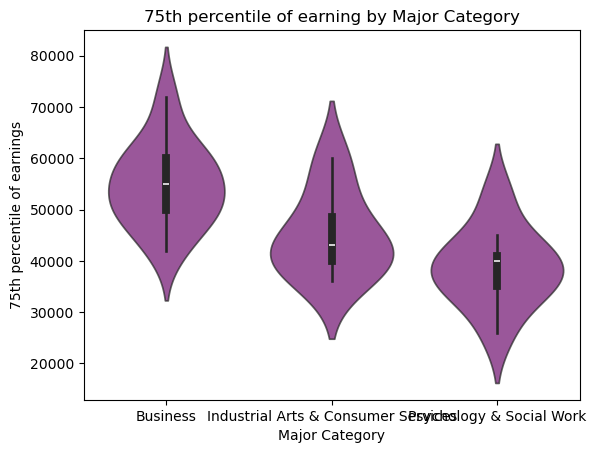

In [12]:
### Your code below this line
indices_for_subset = df['Major_category'].isin(['Business', 'Psychology & Social Work', 'Industrial Arts & Consumer Services'])
df_subset = df[indices_for_subset]

sns.violinplot(data = df_subset, x = 'Major_category', y = 'P75th', color = 'purple', alpha = 0.7)

plt.xlabel('Major Category')
plt.ylabel('75th percentile of earnings')
plt.title('75th percentile of earning by Major Category')

### **Joint Plots**

In the last lab, we learned how to visualize scatterplot to visualize the relationship between two variables. However, scatter plots do not effectively show the magnitude and direction of the correlation between two variables. Remember the plot we discussed in class from this article? Here, in addition to the scatterplot, a **line** helped us visualize the nature of association between the two variables. 

To accomplish this simply, we can use regression jointplots using seaborn's `jointplot` function.

**What is a Jointplot?** A jointplot combines:

 - A main scatter plot showing the relationship between two variables
 - Marginal distributions on the sides (histograms or KDE plots)

When using `kind="reg"`, it adds a regression line to show the linear relationship between variables.  

Let's create a jointplot showing the relationship between median income and unemployment rate. First, let's just plot the data without a line.

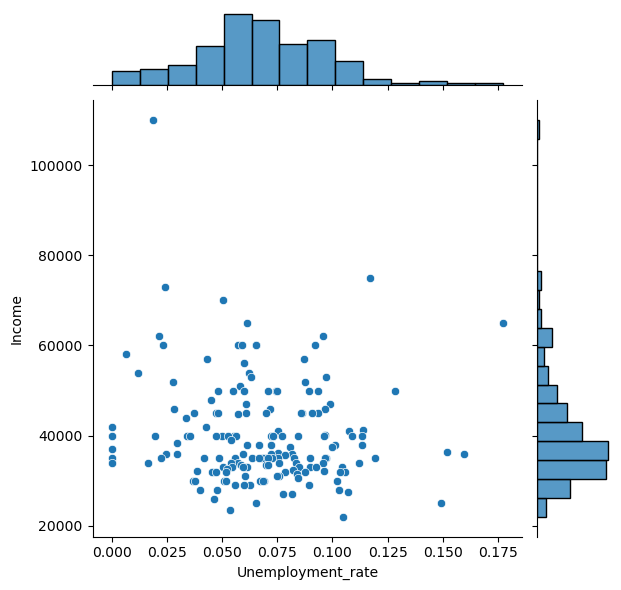

In [13]:
sns.jointplot(data=df, x='Unemployment_rate', y='Income')

plt.show()

We created a jointplot with sns.jointplot() specifying:

 - `data`: Our dataframe
 - `x` and `y`: Our variables of interest

Great! What if we want the color to be different for different college majors? Let's try that with the `hue` parameter.

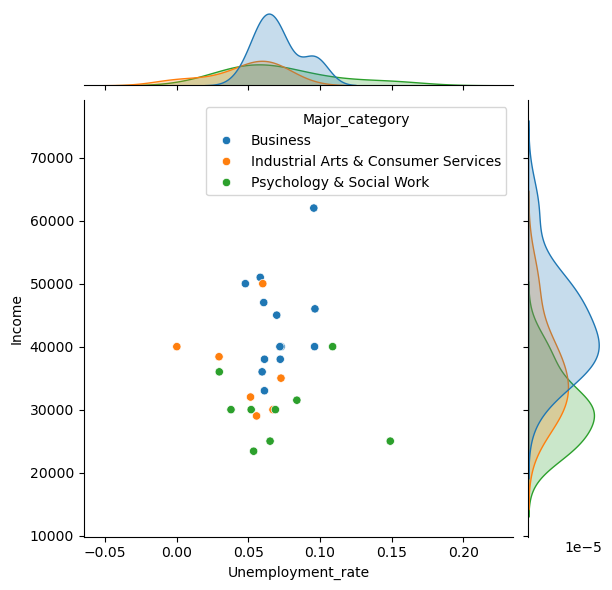

In [14]:
sns.jointplot(data=df_subset, x='Unemployment_rate', y='Income', hue='Major_category')

plt.show()

Now, instead of different colors, we want all the points to have the same color. Let's try that with the `color` parameter and change the data points to the color purple. 

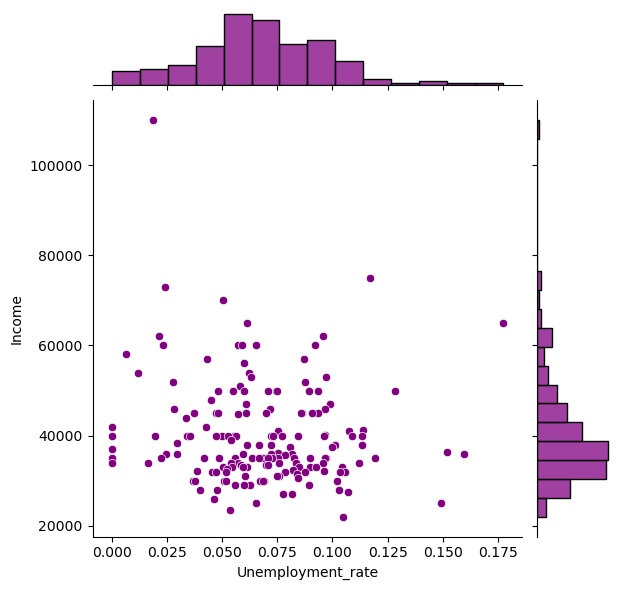

In [15]:
sns.jointplot(data=df, x='Unemployment_rate', y='Income', color = 'purple')

plt.show()

**IMPORTANT** Now, we want to add a line to this plot. We can do this by setting the parameter `kind` to `reg`. What does this mean? It adds a "regression line" to the scatter plot, which helps us see the magnitude (slope) and direction (positive or negative) of the relationship between the two variables.

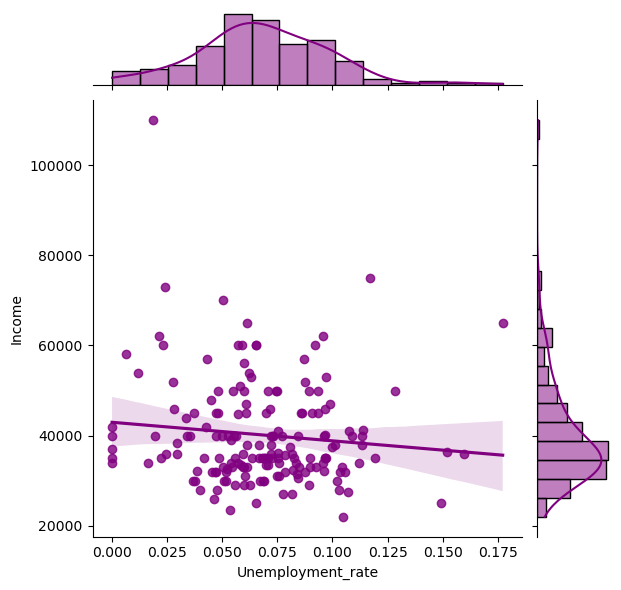

In [16]:
sns.jointplot(data=df, x='Unemployment_rate', y='Income', kind='reg', color = 'purple')

plt.show()

Great! Let's now add a title using the `plt.title` function.

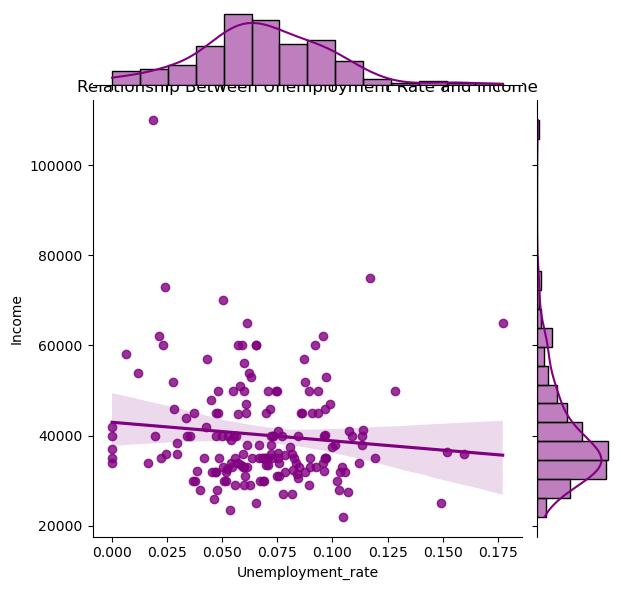

In [19]:
sns.jointplot(data=df, x='Unemployment_rate', y='Income', kind='reg', color = 'purple')

# Add title
plt.title('Relationship Between Unemployment Rate and Income')

plt.show()

Given the special configuration of this plot type, the title appears at an inconvenient location. Let's locate it above the plot using the `suptitle` function from matplotlib, which puts a "super" title at the top center of the figure.

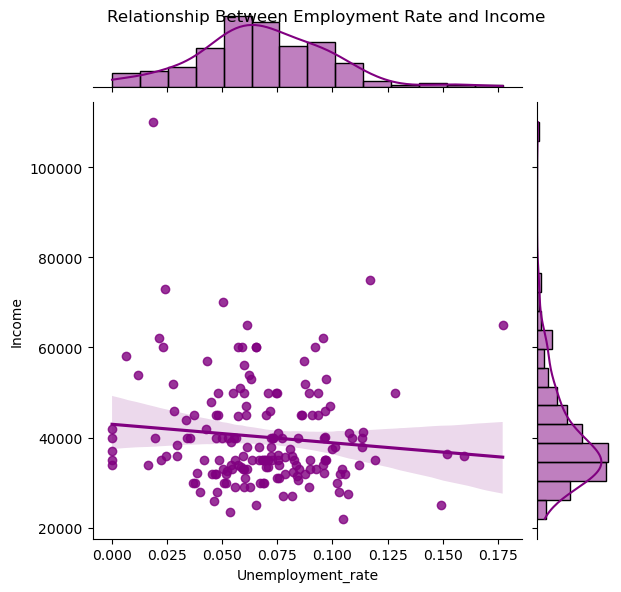

In [20]:
sns.jointplot(data=df, x='Unemployment_rate', y='Income', kind='reg', color = 'purple')

# Add title
plt.suptitle('Relationship Between Employment Rate and Income')

plt.show()

#### Practice Question

Create a jointplot showing the relationship between the percentage of women in a major (`ShareWomen`) and median income (`Income`).\
Note: in order to see the "relationship" clearly, we need to see a line that helps us understand the direction of the relationship.

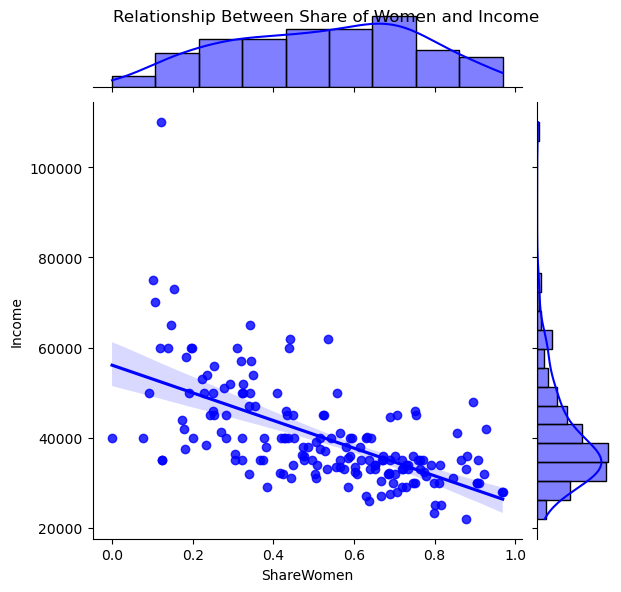

In [21]:
### Your code below this line
sns.jointplot(data=df, x='ShareWomen', y='Income', kind='reg', color = 'blue')

# Add title
plt.suptitle('Relationship Between Share of Women and Income')

plt.show()

#### Practice Question

Create a jointplot showing the relationship between the income (`Income`) and non college jobs (`Non_college_jobs`), grouped by `Major_category`.

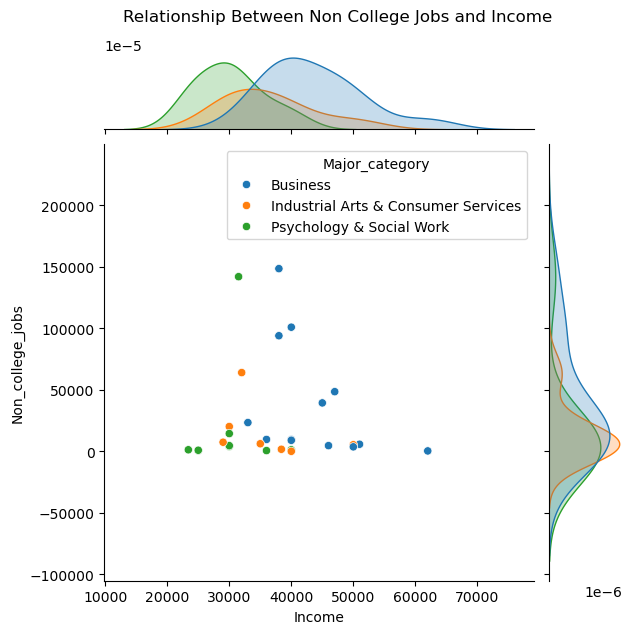

In [38]:
### Your code below this line
sns.jointplot(data=df_subset, x='Income', y='Non_college_jobs', hue='Major_category')

# Add title
plt.suptitle('Relationship Between Non College Jobs and Income', y = 1.05, fontsize = 12)

plt.show()